<a href="https://colab.research.google.com/github/Jude-Ufoh/Pytorch/blob/main/Classification/Pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classification is all about determining if something is one thing o the other

#### making our own dataset

In [32]:
from sklearn.datasets import make_circles


# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [33]:
# Granted that the circle has been imported, we now  make a dataframe out of the circle
import pandas as pd
circles = pd.DataFrame({'X1': X[:,0], 'X2':X[:,1], 'label':y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [34]:
# Since each pair of the circle has a value of either o or 1, it means that the problem is binary classification.
# Checking the different labels

circles.label.value_counts()

,count
label,
1,500
0,500


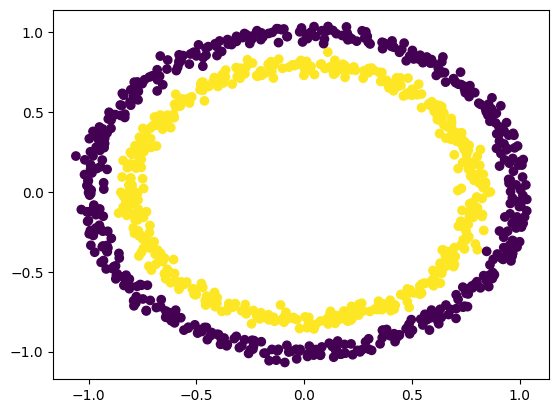

In [50]:
# visualising the the data with a plot
import matplotlib.pyplot as plt
plt.scatter(x=circles['X1'],
            y=circles['X2'],
            c=circles['label'])

In [36]:
# We now a build a pytorch model that can classifythe above dots into yellow or blue d
# We now proceed to build a pytorch model to classify the dots
# First we check the shape
X.shape, y.shape

((1000, 2), (1000,))

#Turning the data to tensors
## Our Data has been in numpy array but pytorch can only work with tensors


In [37]:
import torch
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [38]:
# Turning the data into into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [39]:


# View the first five samples
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [40]:
#Splitting the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#Checking the length of each split
len(X_train,), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [41]:
# Since the model is a circle, we cannot use a linear model. We build the model with non linearity. to build a model with non linearity, we use an activation function
# Basically, we build our model by subclassing the nn.Module and applying a non linaer activation function.
# Since we have two inputs (X1 and X2), our model will beasically have two inputs

from torch import nn
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 =nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_0 = CircleModel().to(device)
model_0


CircleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [42]:
# Creating a binary classification loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [43]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

## Training the model (Building the Training Loop)

In [45]:
torch.manual_seed(42)
epochs = 1000

#Put all data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#building the training loop
for epoch in range(epochs):
    model_0.train()
    # for the forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2 Calculating the loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true =y_train, y_pred=y_pred)

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    #5. Testing
    optimizer.step()

    #  Testing
    model_0.eval
    with torch.inference_mode():
      # 1. forward pass
      test_logits = model_0(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true =y_test, y_pred=test_pred)
      #Print out what's happening
      if epoch % 200 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.56818, Accuracy: 87.75% | Test loss: 0.57378, Test acc: 86.50%
Epoch: 200 | Loss: 0.37056, Accuracy: 97.75% | Test loss: 0.40595, Test acc: 92.00%
Epoch: 400 | Loss: 0.17180, Accuracy: 99.50% | Test loss: 0.22108, Test acc: 97.50%
Epoch: 600 | Loss: 0.09123, Accuracy: 99.88% | Test loss: 0.12741, Test acc: 99.50%
Epoch: 800 | Loss: 0.05773, Accuracy: 99.88% | Test loss: 0.08672, Test acc: 99.50%


In [46]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

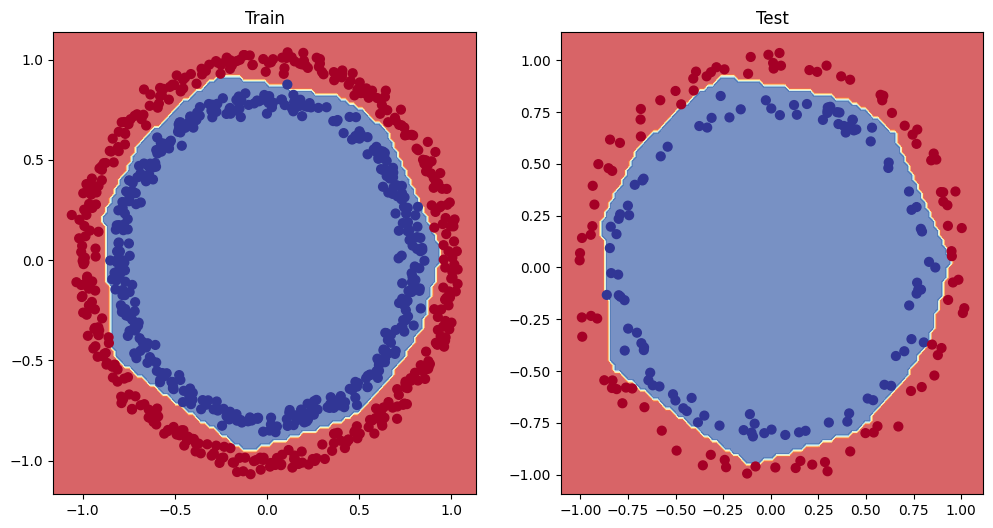

In [48]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test) # model_3 = has non-linearity